# CineMatch AI
## Sistema de recomendación inteligente basado en filtrado colaborativo

Este notebook documenta el análisis técnico del prototipo CineMatch AI. El objetivo es construir un sistema de recomendación de películas usando patrones históricos de valoración de usuarios.

MovieLens se utiliza como dataset de referencia. El foco del análisis está en entender los datos, construir una matriz usuario-película, calcular similitud del coseno entre películas y evaluar de forma exploratoria la coherencia de las recomendaciones.

## 1. Configuración del entorno

La celda siguiente localiza automáticamente la raíz del proyecto. Esto permite ejecutar el notebook tanto desde la carpeta raíz como desde `notebooks/`.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


def find_project_root():
    current_dir = Path.cwd().resolve()
    for candidate in [current_dir, *current_dir.parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError(
        "No se pudo localizar la raíz del proyecto. Ejecuta el notebook desde la raíz "
        "del repositorio o desde la carpeta notebooks/."
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"

ratings_path = DATA_DIR / "ratings.csv"
movies_path = DATA_DIR / "movies.csv"

if not ratings_path.exists() or not movies_path.exists():
    raise FileNotFoundError(
        "No se encontraron ratings.csv y movies.csv. Ambos archivos deben estar "
        "en la carpeta data/ del proyecto."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_processing import (
    build_dataset_summary,
    build_item_similarity_matrix,
    build_user_movie_matrix,
    filter_ratings,
    get_movie_rating_stats,
    load_movielens_data,
)
from src.recommender import MovieRecommender, recommendations_to_dataframe

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Carpeta de datos: {DATA_DIR}")

Raíz del proyecto: C:\Users\Alberto\OneDrive\Desktop\Evolve_Talent_Day\Proyecto-Master-DataScience-Evolve-AlbertoMartinez
Carpeta de datos: C:\Users\Alberto\OneDrive\Desktop\Evolve_Talent_Day\Proyecto-Master-DataScience-Evolve-AlbertoMartinez\data


## 2. Carga y validación de datos

Se cargan los archivos `ratings.csv` y `movies.csv` desde `data/`. Antes de construir el recomendador, se revisan columnas, tamaños y valores faltantes.

In [2]:
ratings, movies = load_movielens_data(data_dir=DATA_DIR)

print("Dimensiones de los datasets")
print(f"ratings: {ratings.shape[0]:,} filas y {ratings.shape[1]} columnas")
print(f"movies: {movies.shape[0]:,} filas y {movies.shape[1]} columnas")

print("\nColumnas de ratings:", list(ratings.columns))
print("Columnas de movies:", list(movies.columns))

missing_values = pd.DataFrame({
    "ratings": ratings.isna().sum(),
    "movies": movies.isna().sum(),
}).fillna(0).astype(int)

missing_values

Dimensiones de los datasets
ratings: 500,000 filas y 4 columnas
movies: 45,447 filas y 3 columnas

Columnas de ratings: ['userId', 'movieId', 'rating', 'timestamp']
Columnas de movies: ['movieId', 'title', 'genres']


,ratings,movies
genres,0,0
movieId,0,0
rating,0,0
timestamp,0,0
title,0,0
userId,0,0


In [3]:
ratings.head(), movies.head()

(   userId  movieId  rating   timestamp
 0       1      110     1.0  1425941529
 1       1      147     4.5  1425942435
 2       1      858     5.0  1425941523
 3       1     1221     5.0  1425941546
 4       1     1246     5.0  1425941556,
    movieId                               title  \
 0        1                    Toy Story (1995)   
 1        2                      Jumanji (1995)   
 2        3             Grumpier Old Men (1995)   
 3        4            Waiting to Exhale (1995)   
 4        5  Father of the Bride Part II (1995)   
 
                                         genres  
 0  Adventure|Animation|Children|Comedy|Fantasy  
 1                   Adventure|Children|Fantasy  
 2                               Comedy|Romance  
 3                         Comedy|Drama|Romance  
 4                                       Comedy  )

## 3. Análisis exploratorio

El análisis exploratorio permite entender la escala del problema: cantidad de usuarios, películas, ratings y distribución de valoraciones. También ayuda a justificar el filtrado posterior.

In [4]:
original_users = ratings["userId"].nunique()
original_rated_movies = ratings["movieId"].nunique()
original_density = len(ratings) / (original_users * original_rated_movies)

eda_summary = pd.DataFrame({
    "Métrica": [
        "Ratings originales",
        "Películas en catálogo",
        "Películas con ratings",
        "Usuarios originales",
        "Rating medio",
        "Densidad inicial",
    ],
    "Valor": [
        f"{len(ratings):,}",
        f"{len(movies):,}",
        f"{original_rated_movies:,}",
        f"{original_users:,}",
        f"{ratings['rating'].mean():.2f}",
        f"{original_density:.2%}",
    ],
})

eda_summary

,Métrica,Valor
0,Ratings originales,"500,000"
1,Películas en catálogo,"45,447"
2,Películas con ratings,"15,534"
3,Usuarios originales,"5,178"
4,Rating medio,3.55
5,Densidad inicial,0.62%


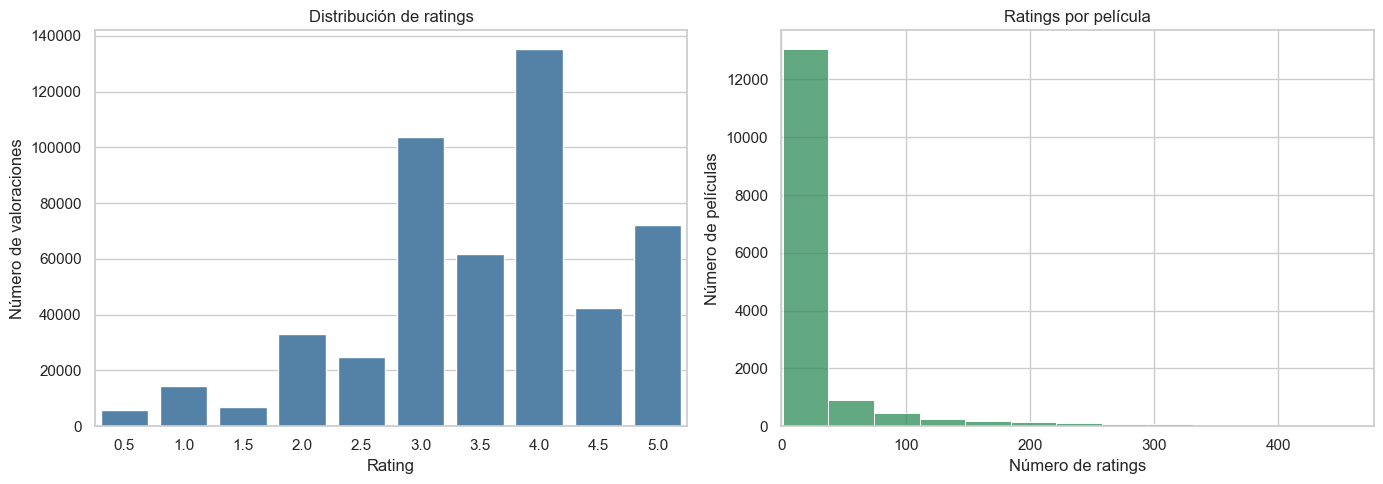

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rating_counts = ratings["rating"].value_counts().sort_index()
sns.barplot(x=rating_counts.index.astype(str), y=rating_counts.values, ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de ratings")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Número de valoraciones")

movie_rating_stats = get_movie_rating_stats(ratings)
sns.histplot(movie_rating_stats["count"], bins=50, ax=axes[1], color="seagreen")
axes[1].set_title("Ratings por película")
axes[1].set_xlabel("Número de ratings")
axes[1].set_ylabel("Número de películas")
axes[1].set_xlim(0, movie_rating_stats["count"].quantile(0.99))

plt.tight_layout()
plt.show()

### Interpretación

- `Distribución de ratings`: La mayoría de valoraciones se concentran entre 3 y 5 puntos, especialmente en ratings de 4. Esto indica un sesgo positivo habitual en plataformas de recomendación, donde los usuarios tienden a valorar principalmente películas que les han gustado.
- `Ratings por película`: La distribución de ratings por película es muy desigual. La mayoría de películas tienen pocas valoraciones, mientras que un grupo reducido concentra gran parte de la actividad.Este comportamiento es típico en sistemas reales y refleja un catálogo con alta dispersión y popularidad desigual entre películas.

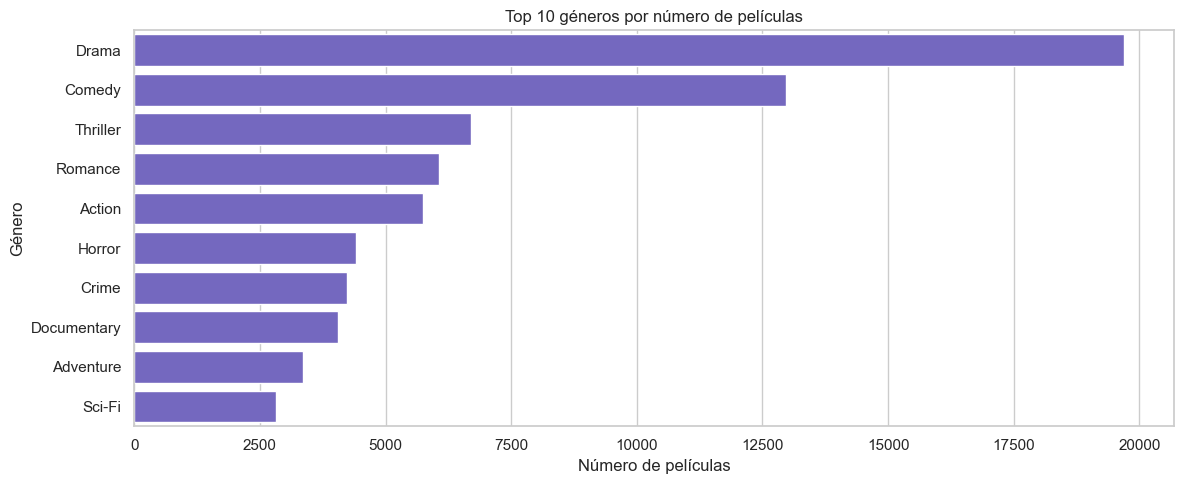

In [6]:
genres = (
    movies["genres"]
    .dropna()
    .loc[lambda series: series != "(no genres listed)"]
    .str.split("|")
    .explode()
)

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_genres.values, y=top_genres.index, color="slateblue")
plt.title("Top 10 géneros por número de películas")
plt.xlabel("Número de películas")
plt.ylabel("Género")
plt.tight_layout()
plt.show()

## 4. Filtrado y matriz usuario-película

Se filtran películas con al menos 20 ratings y usuarios con al menos 10 ratings. Este paso reduce la cobertura del catálogo, pero aumenta la fiabilidad de las similitudes porque mantiene películas con suficiente historial de valoración.

Tras el filtrado se conservan 446.702 de 500.000 ratings originales.

In [7]:
MIN_MOVIE_RATINGS = 20
MIN_USER_RATINGS = 10

filtered_ratings = filter_ratings(
    ratings,
    min_movie_ratings=MIN_MOVIE_RATINGS,
    min_user_ratings=MIN_USER_RATINGS,
)

user_movie_matrix = build_user_movie_matrix(filtered_ratings)

filter_summary = pd.DataFrame({
    "Métrica": [
        "Ratings originales",
        "Ratings finales",
        "Usuarios activos",
        "Películas finales",
        "Densidad matriz usuario-película",
    ],
    "Valor": [
        f"{len(ratings):,}",
        f"{len(filtered_ratings):,}",
        f"{filtered_ratings['userId'].nunique():,}",
        f"{filtered_ratings['movieId'].nunique():,}",
        f"{np.count_nonzero(user_movie_matrix.values) / user_movie_matrix.size:.2%}",
    ],
})

filter_summary

,Métrica,Valor
0,Ratings originales,"500,000"
1,Ratings finales,"446,702"
2,Usuarios activos,"4,356"
3,Películas finales,"3,728"
4,Densidad matriz usuario-película,2.75%


In [8]:
coverage = filtered_ratings["movieId"].nunique() / len(movies)
retained_ratings = len(filtered_ratings) / len(ratings)

print(f"Cobertura del sistema: {filtered_ratings['movieId'].nunique():,} películas sobre {len(movies):,} ({coverage:.1%})")
print(f"Ratings conservados: {len(filtered_ratings):,} de {len(ratings):,} ({retained_ratings:.1%})")
print(f"Dimensiones de la matriz usuario-película: {user_movie_matrix.shape[0]:,} x {user_movie_matrix.shape[1]:,}")

Cobertura del sistema: 3,728 películas sobre 45,447 (8.2%)
Ratings conservados: 446,702 de 500,000 (89.3%)
Dimensiones de la matriz usuario-película: 4,356 x 3,728


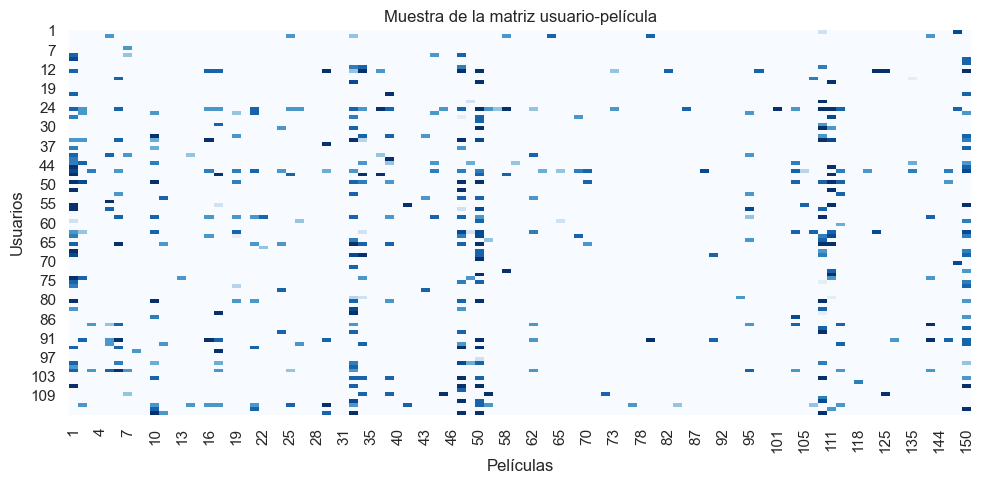

In [9]:
plt.figure(figsize=(10, 5))
sample_matrix = user_movie_matrix.iloc[:100, :100]
sns.heatmap(sample_matrix, cmap="Blues", cbar=False)
plt.title("Muestra de la matriz usuario-película")
plt.xlabel("Películas")
plt.ylabel("Usuarios")
plt.tight_layout()
plt.show()

### Interpretación

El filtrado reduce ruido y elimina películas con muy pocas valoraciones y usuarios poco activos. Aunque esto disminuye la cobertura total del catálogo, mejora la estabilidad de las similitudes calculadas posteriormente.

Tras el filtrado se conservan más del 89% de los ratings originales, manteniendo una base suficientemente representativa para generar recomendaciones consistentes.

La matriz usuario-película sigue siendo dispersa, algo habitual en sistemas de recomendación reales, ya que cada usuario solo interactúa con una pequeña parte del catálogo.

## 5. Cálculo de similitud del coseno

La matriz usuario-película se transpone para representar cada película como un vector de ratings de usuarios. Después se calcula la similitud del coseno entre películas.

La similitud del coseno no mide precisión supervisada. En este proyecto se usa como criterio de cercanía entre películas según patrones de valoración.

In [10]:
similarity_df = build_item_similarity_matrix(user_movie_matrix)
summary = build_dataset_summary(ratings, movies, filtered_ratings, user_movie_matrix, similarity_df)

similarity_values = similarity_df.values[np.triu_indices_from(similarity_df.values, k=1)]

similarity_summary = pd.DataFrame({
    "Métrica": [
        "Películas comparadas",
        "Pares únicos de películas",
        "Similitud media entre pares",
        "Similitud mediana entre pares",
        "Similitud máxima entre pares",
    ],
    "Valor": [
        f"{similarity_df.shape[0]:,}",
        f"{len(similarity_values):,}",
        f"{similarity_values.mean():.4f}",
        f"{np.median(similarity_values):.4f}",
        f"{similarity_values.max():.4f}",
    ],
})

similarity_summary

,Métrica,Valor
0,Películas comparadas,"3,728"
1,Pares únicos de películas,"6,947,128"
2,Similitud media entre pares,0.0907
3,Similitud mediana entre pares,0.0785
4,Similitud máxima entre pares,0.8400


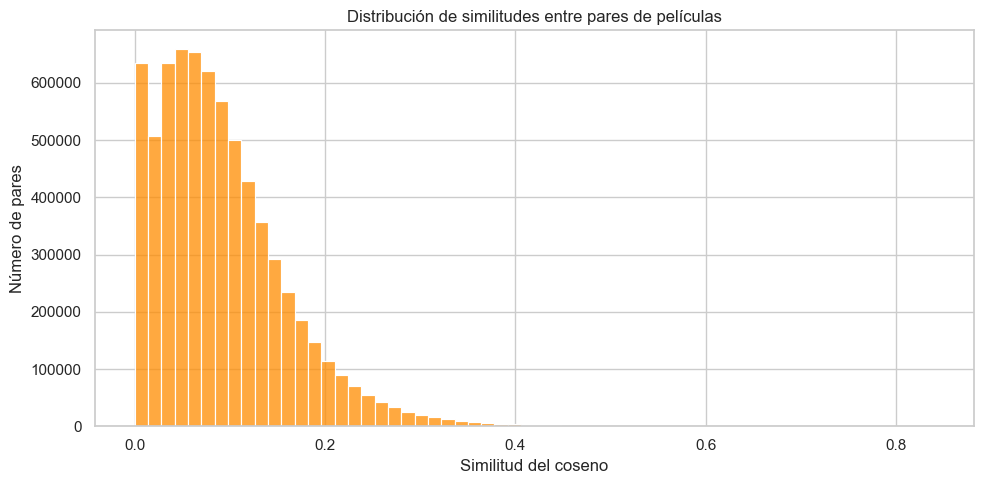

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(similarity_values, bins=60, color="darkorange")
plt.title("Distribución de similitudes entre pares de películas")
plt.xlabel("Similitud del coseno")
plt.ylabel("Número de pares")
plt.tight_layout()
plt.show()

### Interpretación

La similitud del coseno permite medir qué películas reciben patrones de valoración parecidos entre usuarios.

La distribución observada muestra que la mayoría de pares de películas tienen similitudes bajas, mientras que un grupo reducido presenta relaciones más fuertes. Esto es esperable en catálogos amplios, donde solo algunas películas comparten audiencias claramente similares.

La similitud media global es baja porque la mayor parte de películas no están directamente relacionadas entre sí, pero el sistema sigue siendo capaz de identificar vecinos relevantes para generar recomendaciones útiles.

## 6. Ejemplos de recomendación

Se instancia el recomendador reutilizando la matriz de similitud calculada. Los ejemplos son reproducibles y muestran título, géneros y score de similitud.

In [12]:
recommender = MovieRecommender(similarity_df=similarity_df, movies_df=movies)


def show_recommendations(title, top_n=5):
    selected_movie, recommendations = recommender.recommend_by_title(title, top_n=top_n)
    print(f"Película base: {selected_movie['title']}")
    print(f"Géneros base: {selected_movie['genres']}")
    return recommendations_to_dataframe(recommendations)

In [13]:
show_recommendations("Scarface", top_n=5)

Película base: Scarface (1983)
Géneros base: Action|Crime|Drama


,Titulo,Generos,Score de similitud
0,Reservoir Dogs (1992),Crime|Mystery|Thriller,0.4485
1,Snatch (2000),Comedy|Crime|Thriller,0.4313
2,Goodfellas (1990),Crime|Drama,0.4310
3,Full Metal Jacket (1987),Drama|War,0.4258
4,Sin City (2005),Action|Crime|Film-Noir|Mystery|Thriller,0.4246


In [14]:
show_recommendations("Memento", top_n=5)

Película base: Memento (2000)
Géneros base: Mystery|Thriller


,Titulo,Generos,Score de similitud
0,Fight Club (1999),Action|Crime|Drama|Thriller,0.6327
1,"Matrix, The (1999)",Action|Sci-Fi|Thriller,0.5943
2,Eternal Sunshine of the Spotless Mind (2004),Drama|Romance|Sci-Fi,0.5891
3,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy,0.5683
4,American Beauty (1999),Drama|Romance,0.5669


In [15]:
show_recommendations("Star Wars", top_n=5)

Película base: Star Wars: Episode IV - A New Hope (1977)
Géneros base: Action|Adventure|Sci-Fi


,Titulo,Generos,Score de similitud
0,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,0.7941
1,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi,0.7673
2,Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure,0.6665
3,"Matrix, The (1999)",Action|Sci-Fi|Thriller,0.6195
4,Indiana Jones and the Last Crusade (1989),Action|Adventure,0.5916


## 7. Evaluación exploratoria

La evaluación se realiza sobre las 100 películas con más ratings dentro del conjunto filtrado. Para cada película se generan 10 recomendaciones.

Se reportan dos indicadores descriptivos:

- similitud media top-N: media de los scores de similitud del coseno en las recomendaciones generadas;
- consistencia de géneros: proporción de recomendaciones que comparten al menos un género con la película base.

La consistencia de géneros es una validación exploratoria. No es una métrica supervisada ni debe interpretarse como medida supervisada de acierto del modelo.

In [16]:
def evaluate_recommendations(recommender, filtered_ratings_df, sample_size=100, top_n=10):
    movie_stats_filtered = get_movie_rating_stats(filtered_ratings_df)
    sample_movie_ids = movie_stats_filtered.nlargest(sample_size, "count")["movieId"].tolist()

    all_similarities = []
    genre_consistency_scores = []
    evaluated_movies = 0

    for movie_id in sample_movie_ids:
        movie_info = recommender.get_movie_info(movie_id)
        if not movie_info:
            continue

        recommendations = recommender.recommend_by_id(movie_id, top_n=top_n)
        if not recommendations:
            continue

        evaluated_movies += 1
        all_similarities.extend([rec["similarity_score"] for rec in recommendations])

        base_genres = set(movie_info["genres"].split("|")) if movie_info["genres"] else set()
        genre_matches = 0

        for rec in recommendations:
            rec_genres = set(rec["genres"].split("|")) if rec["genres"] else set()
            if base_genres & rec_genres:
                genre_matches += 1

        genre_consistency_scores.append(genre_matches / len(recommendations))

    return {
        "sample_size": sample_size,
        "top_n": top_n,
        "evaluated_movies": evaluated_movies,
        "similarity_mean": float(np.mean(all_similarities)),
        "similarity_min": float(np.min(all_similarities)),
        "similarity_max": float(np.max(all_similarities)),
        "similarity_std": float(np.std(all_similarities)),
        "genre_consistency_mean": float(np.mean(genre_consistency_scores)),
        "genre_consistency_gt_50": int(np.sum(np.array(genre_consistency_scores) > 0.5)),
    }


evaluation = evaluate_recommendations(
    recommender=recommender,
    filtered_ratings_df=filtered_ratings,
    sample_size=100,
    top_n=10,
)

evaluation_summary = pd.DataFrame({
    "Métrica": [
        "Películas evaluadas",
        "Recomendaciones por película",
        "Similitud media top-N",
        "Similitud mínima top-N",
        "Similitud máxima top-N",
        "Desviación estándar de similitud",
        "Consistencia media de géneros",
        "Películas con consistencia de géneros superior al 50%",
    ],
    "Valor": [
        f"{evaluation['evaluated_movies']:,}",
        f"{evaluation['top_n']:,}",
        f"{evaluation['similarity_mean']:.4f}",
        f"{evaluation['similarity_min']:.4f}",
        f"{evaluation['similarity_max']:.4f}",
        f"{evaluation['similarity_std']:.4f}",
        f"{evaluation['genre_consistency_mean']:.1%}",
        f"{evaluation['genre_consistency_gt_50']:,} de {evaluation['evaluated_movies']:,}",
    ],
})

evaluation_summary

,Métrica,Valor
0,Películas evaluadas,100
1,Recomendaciones por película,10
2,Similitud media top-N,0.5662
3,Similitud mínima top-N,0.4211
4,Similitud máxima top-N,0.8400
5,Desviación estándar de similitud,0.0620
6,Consistencia media de géneros,81.5%
7,Películas con consistencia de géneros superior...,94 de 100


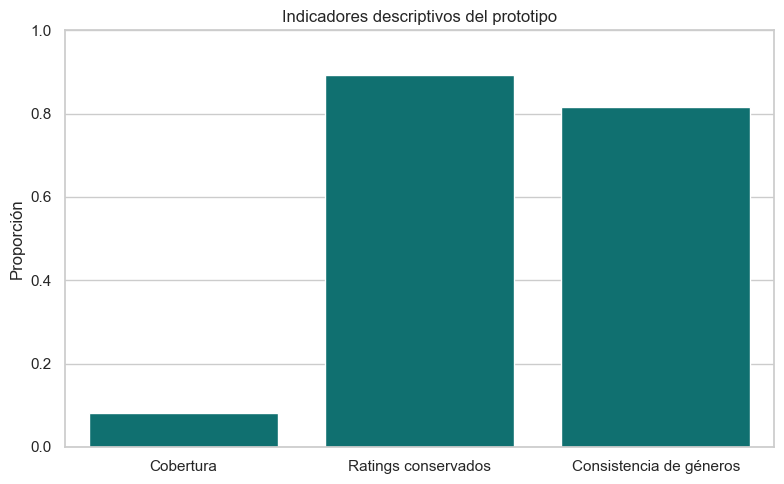

In [17]:
plt.figure(figsize=(8, 5))
metrics_plot = pd.DataFrame({
    "Indicador": ["Cobertura", "Ratings conservados", "Consistencia de géneros"],
    "Valor": [coverage, retained_ratings, evaluation["genre_consistency_mean"]],
})
sns.barplot(data=metrics_plot, x="Indicador", y="Valor", color="teal")
plt.ylim(0, 1)
plt.title("Indicadores descriptivos del prototipo")
plt.ylabel("Proporción")
plt.xlabel("")
plt.tight_layout()
plt.show()

### Interpretación

La evaluación exploratoria muestra que las recomendaciones generadas mantienen una coherencia razonable entre géneros y patrones de valoración.

La consistencia media de géneros supera el 80%, lo que indica que el sistema suele recomendar películas relacionadas temáticamente con la película de referencia.

Al mismo tiempo, la cobertura del catálogo sigue siendo limitada debido al filtrado aplicado, reflejando uno de los compromisos habituales en sistemas de recomendación: mejorar fiabilidad sacrificando parte del catálogo disponible.

## 8. Conclusiones, limitaciones y próximos pasos

Conclusiones principales:

- El sistema conserva 446.702 de 500.000 ratings, por lo que mantiene la mayor parte de la señal disponible.
- La cobertura final es de 3.728 películas sobre 45.447, equivalente al 8,2% del catálogo completo.
- El filtrado reduce cobertura, pero aumenta la fiabilidad al trabajar con películas que tienen suficiente historial de valoración.
- La matriz usuario-película tiene una densidad del 2,75%, por lo que el problema mantiene la naturaleza de matriz dispersa de tamaño medio.
- La evaluación exploratoria sobre 100 películas populares muestra una similitud media top-N de 0,5662 y una consistencia media de géneros del 81,5%.

Limitaciones:

- El sistema no resuelve cold start para películas o usuarios nuevos.
- Las recomendaciones se basan en patrones históricos de ratings, no en contenido semántico profundo.
- La consistencia de géneros es una validación exploratoria y no sustituye una evaluación supervisada de ranking.
- La matriz de similitud se calcula de forma batch, sin actualización incremental.

Próximos pasos:

- Incorporar filtrado híbrido combinando ratings y metadatos de películas.
- Evaluar métricas de ranking como Precision@K, Recall@K o NDCG si se define un protocolo offline adecuado.
- Precalcular y versionar artefactos derivados para acelerar la demo sin incluir archivos de datos originales en GitHub.
- Mejorar la interfaz Streamlit como pieza principal de presentación del proyecto.